# Dashboard GAC · Etapa I. Modelado explicativo (Análisis comparativo)
## a) Extracción de características – Análisis univariado

**Bases de datos:**
- `Analisis_GAC_Full7agosto_2026_Bitacora_de_Piso_.csv` → base limpia: **`Bitacora_Piso_Limpia.csv`**
- `Analisis_GAC_Full7agosto_2026_Leads_Reales_.csv` → base limpia: **`Leads_Reales_Limpia.csv`**

**Variables analizadas (no se repiten Estatus Lead, Producto ni Interés de leads):**

| Base | Variable | Tipo de análisis | Razón |
|---|---|---|---|
| Bitácora de Piso | `Asesor` | Categórica (frecuencia de visitas atendidas) | Mide cómo se reparte la carga de clientes de piso entre asesores |
| Bitácora de Piso | `Prueba_Manejo` (PDM 0/1) | Binaria numérica (Sí / No) | Primer paso del embudo de venta en piso; indica qué tanto se convierte una visita en prueba |
| Leads Reales | `Nivel_Efectividad` (a partir de `Efectividad_Leads` %) | Numérica transformada a categórica (Baja / Media / Alta) | Clasifica cada mes según la calidad de los leads recibidos |

**Estructura del notebook:**
1. Instalación de librerías
2. Preprocesamiento – Bitácora de Piso (nulos, outliers, transformaciones)
3. Preprocesamiento – Leads Reales (nulos, outliers, transformaciones)
4. Creación del Dashboard (`app.py`) con paleta vino tinto / borgoña / blanco

## 1. Instalación de librerías

In [33]:
#Instalamos la libreria de STREAMLIT
%pip install streamlit

Note: you may need to restart the kernel to use updated packages.


In [34]:
#Instalamos la libreria de PLOTLY
%pip install plotly

Note: you may need to restart the kernel to use updated packages.


In [35]:
#Para instalar npm en visual studio
#1.Desde Google escribir node.js
#2. Instalar la versión más recomendada
! npm install localtunnel


up to date, audited 23 packages in 2s

3 packages are looking for funding
  run `npm fund` for details

2 high severity vulnerabilities

To address all issues (including breaking changes), run:
  npm audit fix --force

Run `npm audit` for details.


In [36]:
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


---
## 2. Preprocesamiento – Bitácora de Piso
### 2.1 Lectura y exploración inicial

In [37]:
#Importamos librerias
import pandas as pd
import numpy as np

In [38]:
#Lectura del archivo csv (utf-8-sig elimina el caracter raro del inicio del archivo)
df_bitacora = pd.read_csv("Analisis GAC Full7agosto 2026(Bitacora de Piso).csv", encoding="utf-8-sig")
#Revisamos dimensiones y primeras filas
print(df_bitacora.shape)
df_bitacora.head()

(234, 30)


,Fecha,Nombre Cliente,Telefono,Asesor,Esatus Lead,PDM,SDC,Estatus de SDC,Venta,Temperatura,...,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29
0,04/01/2025,Ubaldo Cruz Hernandez,NaN,Aurelio,Activo,True,False,NaN,False,Lead InteresBajo,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,04/01/2025,Olivia Cabello,NaN,Pedro,Activo,False,False,NaN,False,Lead InteresBajo,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,04/02/2025,Ana Laura Espinoza,NaN,Mauricio,Activo,True,True,Analisis,True,Lead Interes Alto,...,NaN,NaN,NaN,NaN,NaN,NaN,Items,Items,items,items
3,04/02/2025,Elvis Sanchez,NaN,Aurelio,Activo,False,False,NaN,False,Lead InteresBajo,...,NaN,NaN,NaN,NaN,NaN,NaN,Aurelio,Activo,Aprobada,Lead Interes Medio
4,04/03/2025,Ariel Fernando López,NaN,Alan,Activo,True,False,NaN,False,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Pedro,Cerrado,Condicionada,Lead InteresBajo


In [39]:
#Revisamos los nombres de las columnas (varios traen espacios al final)
print(df_bitacora.columns.tolist())

['Fecha', 'Nombre Cliente ', 'Telefono ', 'Asesor ', 'Esatus Lead', 'PDM', 'SDC', 'Estatus de SDC ', 'Venta', 'Temperatura ', 'Inter Gerente', '¿Por que no hubo prueba de manejo?', '¿Por que no hubo Solicitud de credito?', '¿Por que no hubo intervencion del Gerente?', '¿Por que no hubo proceso wow?', '¿Por que no se ha formalizado la compra?', '5 porques clientes de piso ', 'Comentarios', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29']


In [40]:
#Conteo de nulos por columna
df_bitacora.isnull().sum()

Fecha                                          36
Nombre Cliente                                 37
Telefono                                      234
Asesor                                         38
Esatus Lead                                    37
PDM                                             0
SDC                                            18
Estatus de SDC                                232
Venta                                          18
Temperatura                                   224
Inter Gerente                                  18
¿Por que no hubo prueba de manejo?            218
¿Por que no hubo Solicitud de credito?        220
¿Por que no hubo intervencion del Gerente?    223
¿Por que no hubo proceso wow?                 222
¿Por que no se ha formalizado la compra?      223
5 porques clientes de piso                    226
Comentarios                                   212
Unnamed: 18                                   234
Unnamed: 19                                   234


### 2.2 Limpieza de nombres de columnas y columnas vacías
- Se quitan los espacios sobrantes de los nombres de las columnas.
- Se corrige el nombre `Esatus Lead` → `Estatus_Lead` y se renombran columnas para no usar espacios.
- Se eliminan las columnas `Unnamed` (catálogos auxiliares de Excel, no son registros) y `Telefono` (100% nula).

In [41]:
#Quitamos espacios al inicio y final de los nombres de columnas
df_bitacora.columns = df_bitacora.columns.str.strip()

#Renombramos columnas para trabajar sin espacios
df_bitacora = df_bitacora.rename(columns={'Nombre Cliente': 'Cliente',
                                          'Esatus Lead': 'Estatus_Lead',
                                          'Estatus de SDC': 'Estatus_SDC',
                                          'Inter Gerente': 'Inter_Gerente'})

#Eliminamos columnas "Unnamed" (catálogos de Excel) y Telefono (vacía)
Columnas_Unnamed = df_bitacora.columns[df_bitacora.columns.str.contains('Unnamed')]
df_bitacora = df_bitacora.drop(columns=Columnas_Unnamed)
df_bitacora = df_bitacora.drop(columns=['Telefono'])
print(df_bitacora.shape)

(234, 17)


### 2.3 Tratamiento de nulos
**a) Filas vacías:** el archivo trae renglones en blanco al final. Se eliminan las filas que no tienen `Cliente`, `Asesor` **ni** `Estatus_Lead` (no representan ninguna visita real).

In [42]:
#Eliminamos filas que no tienen cliente, asesor ni estatus (renglones vacíos)
df_bitacora = df_bitacora.dropna(subset=['Cliente', 'Asesor', 'Estatus_Lead'], how='all')
print(df_bitacora.shape)
df_bitacora.isnull().sum()

(197, 17)


Fecha                                           0
Cliente                                         0
Asesor                                          1
Estatus_Lead                                    0
PDM                                             0
SDC                                             0
Estatus_SDC                                   195
Venta                                           0
Temperatura                                   187
Inter_Gerente                                   0
¿Por que no hubo prueba de manejo?            181
¿Por que no hubo Solicitud de credito?        183
¿Por que no hubo intervencion del Gerente?    186
¿Por que no hubo proceso wow?                 185
¿Por que no se ha formalizado la compra?      186
5 porques clientes de piso                    189
Comentarios                                   175
dtype: int64

**b) Columnas con más del 90% de nulos:** `Estatus_SDC`, `Temperatura` y las columnas de texto abierto (¿Por qué no...?, 5 porqués, Comentarios) casi no tienen información. Imputarlas inventaría datos, por lo que se eliminan del análisis univariado.

In [43]:
#Calculamos el porcentaje de nulos por columna
Porcentaje_Nulos = df_bitacora.isnull().mean() * 100
print(Porcentaje_Nulos.round(1))

#Eliminamos las columnas con más de 90% de nulos
Columnas_Eliminar = Porcentaje_Nulos[Porcentaje_Nulos > 90].index
df_bitacora = df_bitacora.drop(columns=Columnas_Eliminar)
print("Columnas eliminadas:", Columnas_Eliminar.tolist())

Fecha                                          0.0
Cliente                                        0.0
Asesor                                         0.5
Estatus_Lead                                   0.0
PDM                                            0.0
SDC                                            0.0
Estatus_SDC                                   99.0
Venta                                          0.0
Temperatura                                   94.9
Inter_Gerente                                  0.0
¿Por que no hubo prueba de manejo?            91.9
¿Por que no hubo Solicitud de credito?        92.9
¿Por que no hubo intervencion del Gerente?    94.4
¿Por que no hubo proceso wow?                 93.9
¿Por que no se ha formalizado la compra?      94.4
5 porques clientes de piso                    95.9
Comentarios                                   88.8
dtype: float64
Columnas eliminadas: ['Estatus_SDC', 'Temperatura', '¿Por que no hubo prueba de manejo?', '¿Por que no hubo Solicitud 

**c) Imputación de los nulos restantes:** quedan muy pocos nulos en variables categóricas.
- `Asesor` nulo → `"No identificado"` (no se puede saber quién atendió).
- `Cliente` nulo → `"Sin nombre"`.
- `Estatus_Lead` nulo → se imputa con la **moda**.

In [44]:
#Imputamos nulos en variables categóricas
df_bitacora['Asesor'] = df_bitacora['Asesor'].fillna('No identificado')
df_bitacora['Cliente'] = df_bitacora['Cliente'].fillna('Sin nombre')
df_bitacora['Estatus_Lead'] = df_bitacora['Estatus_Lead'].fillna(df_bitacora['Estatus_Lead'].mode()[0])

#Verificamos que ya no existan nulos
df_bitacora.isnull().sum()

Fecha              0
Cliente            0
Asesor             0
Estatus_Lead       0
PDM                0
SDC                0
Venta              0
Inter_Gerente      0
Comentarios      175
dtype: int64

### 2.4 Transformaciones
- **Texto:** se quitan espacios y se homologan mayúsculas (`venta`, `Venta ` → `Venta`).
- **Asesor:** un mismo asesor aparece escrito de varias formas (`Aurelio`, `Aurelio Torres`, `AUrelio`). Se toma solo el primer nombre en formato título.
- **Fecha:** se convierte a tipo fecha (formato mes/día/año) y se crean `Mes_Num` y `Mes`.
- **Booleanos:** `PDM`, `SDC`, `Venta`, `Inter_Gerente` pasan de TRUE/FALSE a **1/0** (variables numéricas).
- Se crea la etiqueta `Prueba_Manejo` (Sí / No) a partir de `PDM` para los gráficos.

In [45]:
#Homologamos el texto de Estatus_Lead
df_bitacora['Estatus_Lead'] = df_bitacora['Estatus_Lead'].str.strip().str.title()
print(df_bitacora['Estatus_Lead'].value_counts())

Estatus_Lead
Activo        168
Cerrado        18
Venta           7
Finalizado      4
Name: count, dtype: int64


In [46]:
#Homologamos Asesor: quitamos espacios, tomamos el primer nombre y lo ponemos en formato título
df_bitacora['Asesor'] = df_bitacora['Asesor'].str.strip().str.split().str[0].str.title()
#"No identificado" queda como "No" al partir el texto, lo regresamos a su valor
df_bitacora['Asesor'] = df_bitacora['Asesor'].replace('No', 'No identificado')
print(df_bitacora['Asesor'].value_counts())

Asesor
Aurelio            48
Pedro              39
Mauricio           35
Alan               25
Victor             23
Ricardo            13
Nancy               4
Eduardo             2
Casa                2
Marcos              2
Miguel              2
Laura               1
No identificado     1
Name: count, dtype: int64


In [47]:
#Convertimos la fecha (viene en formato mes/día/año)
df_bitacora['Fecha'] = pd.to_datetime(df_bitacora['Fecha'], format='%m/%d/%Y', errors='coerce')

#Creamos el número y nombre del mes
df_bitacora['Mes_Num'] = df_bitacora['Fecha'].dt.month
Nombres_Meses = {1: 'Enero', 2: 'Febrero', 3: 'Marzo', 4: 'Abril', 5: 'Mayo', 6: 'Junio',
                 7: 'Julio', 8: 'Agosto', 9: 'Septiembre', 10: 'Octubre', 11: 'Noviembre', 12: 'Diciembre'}
df_bitacora['Mes'] = df_bitacora['Mes_Num'].map(Nombres_Meses)
print(df_bitacora['Mes'].value_counts())

Mes
Mayo     65
Junio    59
Abril    46
Julio    27
Name: count, dtype: int64


In [48]:
#Convertimos las columnas TRUE/FALSE a numéricas 1/0
for columna in ['PDM', 'SDC', 'Venta', 'Inter_Gerente']:
    df_bitacora[columna] = df_bitacora[columna].astype(str).str.strip().str.upper().map({'TRUE': 1, 'FALSE': 0})

#Creamos la etiqueta de Prueba de Manejo para los gráficos
df_bitacora['Prueba_Manejo'] = df_bitacora['PDM'].map({1: 'Sí', 0: 'No'})
df_bitacora[['PDM', 'SDC', 'Venta', 'Inter_Gerente']].describe()

,PDM,SDC,Venta,Inter_Gerente
count,197.000000,197.000000,197.000000,197.000000
mean,0.380711,0.020305,0.020305,0.157360
std,0.486799,0.141399,0.141399,0.365068
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000


### 2.5 Outliers
**a) Variable numérica – visitas por día:** se cuenta cuántas visitas se registran por día y se revisa con el método del **rango intercuartílico (IQR)**. Los días con muchas visitas son reales (fines de semana, eventos), por lo que **solo se reportan** y no se eliminan filas (cada fila es un cliente real).

**b) Variable categórica – Asesor:** en variables categóricas los "outliers" son categorías con muy pocos registros. Los asesores con **menos de 5 visitas** se agrupan en la categoría **`Otros`** para que no distorsionen los gráficos.

In [49]:
#Contamos visitas por día
Visitas_Dia = df_bitacora.groupby('Fecha').size()

#Calculamos cuartiles y límites del IQR
Q1 = Visitas_Dia.quantile(0.25)
Q3 = Visitas_Dia.quantile(0.75)
IQR = Q3 - Q1
Limite_Inferior = Q1 - 1.5 * IQR
Limite_Superior = Q3 + 1.5 * IQR
print("Límite inferior:", Limite_Inferior, "| Límite superior:", Limite_Superior)

#Mostramos los días fuera de los límites
Outliers_Dia = Visitas_Dia[(Visitas_Dia < Limite_Inferior) | (Visitas_Dia > Limite_Superior)]
print("Días atípicos:")
print(Outliers_Dia)

Límite inferior: -2.0 | Límite superior: 6.0
Días atípicos:
Series([], dtype: int64)


In [50]:
#Agrupamos asesores con menos de 5 visitas en "Otros"
Frecuencia_Asesor = df_bitacora['Asesor'].value_counts()
Asesores_Poco_Frecuentes = Frecuencia_Asesor[Frecuencia_Asesor < 5].index
df_bitacora['Asesor'] = df_bitacora['Asesor'].replace(Asesores_Poco_Frecuentes, 'Otros')
print(df_bitacora['Asesor'].value_counts())

Asesor
Aurelio     48
Pedro       39
Mauricio    35
Alan        25
Victor      23
Otros       14
Ricardo     13
Name: count, dtype: int64


### 2.6 Base limpia final y guardado

In [51]:
#Ordenamos las columnas finales
df_bitacora = df_bitacora[['Fecha', 'Mes_Num', 'Mes', 'Cliente', 'Asesor', 'Estatus_Lead',
                           'PDM', 'SDC', 'Venta', 'Inter_Gerente', 'Prueba_Manejo']]
print(df_bitacora.shape)
print(df_bitacora.isnull().sum().sum(), "nulos restantes")

#Guardamos la base limpia
df_bitacora.to_csv("Bitacora_Piso_Limpia.csv", index=False)
df_bitacora.head()

(197, 11)
0 nulos restantes


,Fecha,Mes_Num,Mes,Cliente,Asesor,Estatus_Lead,PDM,SDC,Venta,Inter_Gerente,Prueba_Manejo
0,2025-04-01,4,Abril,Ubaldo Cruz Hernandez,Aurelio,Activo,1,0,0,1,Sí
1,2025-04-01,4,Abril,Olivia Cabello,Pedro,Activo,0,0,0,1,No
2,2025-04-02,4,Abril,Ana Laura Espinoza,Mauricio,Activo,1,1,1,1,Sí
3,2025-04-02,4,Abril,Elvis Sanchez,Aurelio,Activo,0,0,0,1,No
4,2025-04-03,4,Abril,Ariel Fernando López,Alan,Activo,1,0,0,1,Sí


---
## 3. Preprocesamiento – Leads Reales
### 3.1 Lectura y exploración inicial
El archivo es un reporte de Excel: las dos primeras filas son títulos/totales y debajo de la tabla hay cálculos de objetivos. Se leen **solo las filas de la tabla mensual** (`skiprows=2`, `nrows=30`).

In [52]:
#Lectura del archivo csv (solo la tabla mensual)
df_leads = pd.read_csv("Analisis GAC Full7agosto 2026(Leads Reales).csv", encoding="utf-8-sig",
                       skiprows=2, nrows=30)
print(df_leads.shape)
df_leads

(30, 14)


,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad de Leads,Unnamed: 12,Unnamed: 13
0,2024.0,Enero,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Febrero,543,108.0,33.0,0.0,1.0,389,1.0,12.0,3.1%,72%,NaN,NaN
2,NaN,Marzo,178,37.0,13.0,0.0,0.0,128,1.0,7.0,5.5%,72%,NaN,NaN
3,NaN,Abril,416,79.0,46.0,3.0,0.0,288,1.0,8.0,2.8%,69%,NaN,NaN
4,NaN,Mayo,422,33.0,100.0,17.0,0.0,274,5.0,13.0,4.7%,65%,NaN,NaN
5,NaN,Junio,967,140.0,173.0,31.0,3.0,620,17.0,6.0,1.0%,64%,NaN,NaN
6,NaN,Julio,954,112.0,251.0,12.0,9.0,570,5.0,21.0,3.7%,60%,NaN,NaN
7,NaN,Agosto,"1,409",504.0,324.0,17.0,18.0,546,22.0,17.0,3.1%,39%,NaN,NaN
8,NaN,Septiembre,"1,315",431.0,314.0,14.0,26.0,530,42.0,17.0,3.2%,40%,NaN,NaN
9,NaN,Octubre,"1,973",514.0,606.0,18.0,13.0,822,72.0,23.0,2.8%,42%,NaN,NaN


In [53]:
#Conteo de nulos por columna
df_leads.isnull().sum()

Año                     27
Mes                      1
Total                    2
Ilocalizable             2
No Contesta              2
D. Incorrectos           2
Duplicados               2
Efectivos                2
Abiertos                 2
Ventas                   2
Conversion               2
Efectividad de Leads     2
Unnamed: 12             30
Unnamed: 13             30
dtype: int64

### 3.2 Limpieza de columnas
- Se quitan espacios en los nombres y se renombran sin espacios ni puntos.
- Se eliminan las columnas `Unnamed` (vacías).

In [54]:
#Quitamos espacios de los nombres de columnas
df_leads.columns = df_leads.columns.str.strip()

#Renombramos columnas
df_leads = df_leads.rename(columns={'No Contesta': 'No_Contesta',
                                    'D. Incorrectos': 'D_Incorrectos',
                                    'Efectividad de Leads': 'Efectividad_Leads'})

#Eliminamos columnas vacías "Unnamed"
Columnas_Unnamed = df_leads.columns[df_leads.columns.str.contains('Unnamed')]
df_leads = df_leads.drop(columns=Columnas_Unnamed)
df_leads.columns.tolist()

['Año',
 'Mes',
 'Total',
 'Ilocalizable',
 'No_Contesta',
 'D_Incorrectos',
 'Duplicados',
 'Efectivos',
 'Abiertos',
 'Ventas',
 'Conversion',
 'Efectividad_Leads']

### 3.3 Tratamiento de nulos
- **`Año`** solo aparece en el primer mes de cada año (celdas combinadas en Excel) → se rellena hacia abajo con **`ffill()`**.
- Se elimina la fila vacía del final (sin `Mes`).
- **Enero 2024** no tiene ningún dato registrado → se elimina (imputarla inventaría un mes completo de operación).

In [55]:
#Eliminamos la fila sin mes
df_leads = df_leads.dropna(subset=['Mes'])

#Rellenamos el año hacia abajo
df_leads['Año'] = df_leads['Año'].ffill().astype(int)

#Eliminamos el mes sin registros (Enero 2024)
df_leads = df_leads.dropna(subset=['Total'])
print(df_leads.shape)
df_leads.isnull().sum()

(28, 12)


Año                  0
Mes                  0
Total                0
Ilocalizable         0
No_Contesta          0
D_Incorrectos        0
Duplicados           0
Efectivos            0
Abiertos             0
Ventas               0
Conversion           0
Efectividad_Leads    0
dtype: int64

### 3.4 Transformaciones
- `Mes` trae espacios al final (`"Enero "`) → se limpian.
- Las cantidades vienen como texto con comas (`"1,409"`) → se convierten a número.
- `Conversion` y `Efectividad_Leads` vienen como texto con `%` → se convierten a número (porcentaje).
- Se crean `Mes_Num` y `Periodo` (Año-Mes) para ordenar en el tiempo.

In [56]:
#Limpiamos espacios en el mes
df_leads['Mes'] = df_leads['Mes'].str.strip()

#Convertimos cantidades con coma a números
Columnas_Cantidad = ['Total', 'Ilocalizable', 'No_Contesta', 'D_Incorrectos', 'Duplicados',
                     'Efectivos', 'Abiertos', 'Ventas']
for columna in Columnas_Cantidad:
    df_leads[columna] = df_leads[columna].astype(str).str.replace(',', '').str.strip().astype(float)

#Convertimos porcentajes a número
for columna in ['Conversion', 'Efectividad_Leads']:
    df_leads[columna] = df_leads[columna].astype(str).str.replace('%', '').str.strip().astype(float)

#Creamos el número de mes y el periodo
Numeros_Meses = {'Enero': 1, 'Febrero': 2, 'Marzo': 3, 'Abril': 4, 'Mayo': 5, 'Junio': 6,
                 'Julio': 7, 'Agosto': 8, 'Septiembre': 9, 'Octubre': 10, 'Noviembre': 11, 'Diciembre': 12}
df_leads['Mes_Num'] = df_leads['Mes'].map(Numeros_Meses)
df_leads['Periodo'] = df_leads['Año'].astype(str) + '-' + df_leads['Mes_Num'].astype(str).str.zfill(2)
df_leads.dtypes

Año                    int64
Mes                      str
Total                float64
Ilocalizable         float64
No_Contesta          float64
D_Incorrectos        float64
Duplicados           float64
Efectivos            float64
Abiertos             float64
Ventas               float64
Conversion           float64
Efectividad_Leads    float64
Mes_Num                int64
Periodo                  str
dtype: object

### 3.5 Outliers (método IQR)
Se revisa cada variable numérica con el rango intercuartílico. Como la base es mensual (28 registros), **no se eliminan filas** (se perderían meses completos); los valores fuera de rango se **acotan (winsorización)** al límite inferior o superior con `clip()`.

In [57]:
#Revisamos outliers con IQR en cada variable numérica
Columnas_Numericas = Columnas_Cantidad + ['Conversion', 'Efectividad_Leads']
for columna in Columnas_Numericas:
    Q1 = df_leads[columna].quantile(0.25)
    Q3 = df_leads[columna].quantile(0.75)
    IQR = Q3 - Q1
    Limite_Inferior = Q1 - 1.5 * IQR
    Limite_Superior = Q3 + 1.5 * IQR
    Num_Outliers = ((df_leads[columna] < Limite_Inferior) | (df_leads[columna] > Limite_Superior)).sum()
    print(columna, "-> outliers:", Num_Outliers, "| límites:", round(Limite_Inferior, 2), "a", round(Limite_Superior, 2))
    #Acotamos los valores atípicos a los límites
    df_leads[columna] = df_leads[columna].clip(lower=Limite_Inferior, upper=Limite_Superior).round(2)

Total -> outliers: 1 | límites: 271.38 a 2072.38
Ilocalizable -> outliers: 4 | límites: -120.75 a 319.25
No_Contesta -> outliers: 2 | límites: -159.5 a 540.5
D_Incorrectos -> outliers: 0 | límites: -40.12 a 74.88
Duplicados -> outliers: 1 | límites: -49.5 a 114.5
Efectivos -> outliers: 4 | límites: 303.0 a 999.0
Abiertos -> outliers: 0 | límites: -459.5 a 864.5
Ventas -> outliers: 0 | límites: -6.25 a 61.75
Conversion -> outliers: 0 | límites: 0.27 a 8.28
Efectividad_Leads -> outliers: 0 | límites: 26.88 a 95.88


<Axes: title={'center': 'Después del tratamiento de outliers'}>

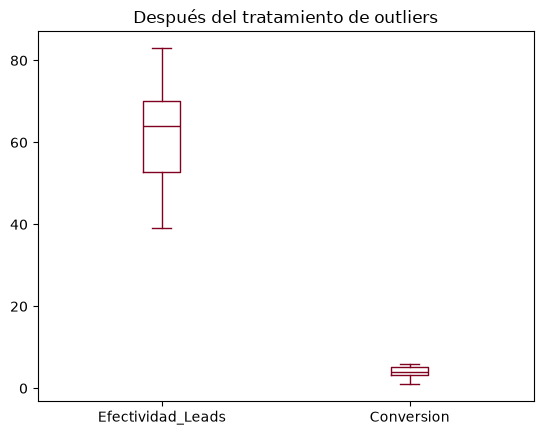

In [58]:
#Boxplot rápido para verificar después del tratamiento
df_leads[['Efectividad_Leads', 'Conversion']].plot(kind='box', color='#800020', title='Después del tratamiento de outliers')

### 3.6 Transformación de variable numérica a categórica: `Nivel_Efectividad`
Para el análisis univariado categórico, `Efectividad_Leads` se discretiza con `pd.cut`:
- **Baja:** ≤ 55%
- **Media:** 55% – 70%
- **Alta:** > 70%

In [59]:
#Discretizamos la efectividad en niveles
df_leads['Nivel_Efectividad'] = pd.cut(df_leads['Efectividad_Leads'], bins=[0, 55, 70, 100],
                                       labels=['Baja', 'Media', 'Alta'])
df_leads['Nivel_Efectividad'].value_counts()

Nivel_Efectividad
Media    14
Baja      8
Alta      6
Name: count, dtype: int64

### 3.7 Base limpia final y guardado

In [60]:
#Ordenamos columnas finales
df_leads = df_leads[['Año', 'Mes_Num', 'Mes', 'Periodo', 'Total', 'Ilocalizable', 'No_Contesta',
                     'D_Incorrectos', 'Duplicados', 'Efectivos', 'Abiertos', 'Ventas',
                     'Conversion', 'Efectividad_Leads', 'Nivel_Efectividad']]
print(df_leads.shape)
print(df_leads.isnull().sum().sum(), "nulos restantes")

#Guardamos la base limpia
df_leads.to_csv("Leads_Reales_Limpia.csv", index=False)
df_leads.head()

(28, 15)
0 nulos restantes


,Año,Mes_Num,Mes,Periodo,Total,Ilocalizable,No_Contesta,D_Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad_Leads,Nivel_Efectividad
1,2024,2,Febrero,2024-02,543.00,108.0,33.0,0.0,1.0,389.0,1.0,12.0,3.1,72.0,Alta
2,2024,3,Marzo,2024-03,271.38,37.0,13.0,0.0,0.0,303.0,1.0,7.0,5.5,72.0,Alta
3,2024,4,Abril,2024-04,416.00,79.0,46.0,3.0,0.0,303.0,1.0,8.0,2.8,69.0,Media
4,2024,5,Mayo,2024-05,422.00,33.0,100.0,17.0,0.0,303.0,5.0,13.0,4.7,65.0,Media
5,2024,6,Junio,2024-06,967.00,140.0,173.0,31.0,3.0,620.0,17.0,6.0,1.0,64.0,Media


---
## 4. Creación del Dashboard (`app.py`)
Se toma como base la **Vista 1 – Extracción de Características** de la plantilla y se agregan:
- **Paleta vino tinto / borgoña / blanco** en todos los gráficos y en el diseño (CSS).
- **Selectores:** base de datos, variable, filtro de meses (multiselect), filtro de años e indicador del heatmap (radio).
- **Tarjetas KPI con íconos** (`st.metric`) y **cuadro de hallazgos** automático.
- **Gráficos:** barras, dona, Pareto, treemap, **heatmap**, **boxplot**, barras en el tiempo y **tabla** de frecuencias con gradiente de color.

In [ ]:
%%writefile app.py
#Creamos el archivo de la APP en el interprete principal (Phyton)
#####################################################
#Importamos librerias
import streamlit as st
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
import numpy as np
######################################################
#Configuración general de la página (título, ícono y ancho completo)
st.set_page_config(page_title="Dashboard GAC", page_icon="🚗", layout="wide")
######################################################
#PALETA DE COLORES: vino tinto, borgoña y blanco
Paleta_Vino = ['#4A0414', '#800020', '#9B1B30', '#B03A48', '#C9747F', '#DDA0A8', '#6D2E46', '#EFD3D7']
Escala_Vino = ['#FFFFFF', '#EFD3D7', '#C9747F', '#9B1B30', '#4A0414']
######################################################
#DISEÑO (CSS): colores del título, barra lateral y tarjetas KPI
st.markdown("""
<style>
h1 {color: #800020;}
h3 {color: #9B1B30;}
[data-testid="stSidebar"] {background-color: #F5E6E8;}
[data-testid="stSidebar"] h1 {color: #4A0414;}
[data-testid="stMetric"] {background-color: #F7ECEE; border-left: 6px solid #800020;
                          padding: 10px; border-radius: 8px;}
[data-testid="stMetric"] * {color: #4A0414;}
</style>
""", unsafe_allow_html=True)
######################################################
#Definimos la instancia
@st.cache_resource
######################################################
#Creamos la función de carga de datos
def load_data():
   #Lectura de las bases ya limpias (generadas en el notebook)
   df_bitacora = pd.read_csv("Bitacora_Piso_Limpia.csv", parse_dates=['Fecha'])
   df_leads = pd.read_csv("Leads_Reales_Limpia.csv")
   #Variables para el análisis univariado
   Lista_Bitacora = ['Asesor', 'Prueba_Manejo']
   Lista_Leads = ['Nivel_Efectividad']
   return df_bitacora, df_leads, Lista_Bitacora, Lista_Leads
###############################################################################
#Cargo los datos obtenidos de la función "load_data"
df_bitacora, df_leads, Lista_Bitacora, Lista_Leads = load_data()
###############################################################################
#CREACIÓN DEL DASHBOARD
##############################################################################
#Generamos los encabezados para la barra lateral (sidebar)
st.sidebar.title("🚗 GAC · Leads y Piso")
#Widget 1: Selectbox
#Menu desplegable para elegir la base de datos
View = st.sidebar.selectbox(label="Base de datos", options=["Bitácora de Piso", "Leads Reales"])
st.sidebar.markdown("---")

##############################################################################
# CONTENIDO DE LA VISTA 1: BITÁCORA DE PISO
if View == "Bitácora de Piso":
    #Widget 2: Selectbox de variables
    Variable_Cat = st.sidebar.selectbox(label="Variables", options=Lista_Bitacora)
    #Widget 3: Multiselect para filtrar meses (ordenados de forma cronológica)
    Orden_Meses = df_bitacora.sort_values('Mes_Num')['Mes'].unique().tolist()
    Meses_Sel = st.sidebar.multiselect(label="Filtrar por mes", options=Orden_Meses, default=Orden_Meses)

    #Filtramos la base con los meses seleccionados
    df_filtro = df_bitacora[df_bitacora['Mes'].isin(Meses_Sel)]
    if df_filtro.empty:
        st.warning("Selecciona al menos un mes en la barra lateral.")
        st.stop()

    #Obtenemos las frecuencias de las categorías de la variable seleccionada
    Tabla_frecuencias = df_filtro[Variable_Cat].value_counts().reset_index()
    #Ajustamos los nombre de las cabeceras de las columnas
    Tabla_frecuencias.columns = ['categorias', 'frecuencia']
    #Agregamos porcentaje y porcentaje acumulado
    Tabla_frecuencias['porcentaje'] = (Tabla_frecuencias['frecuencia'] / Tabla_frecuencias['frecuencia'].sum() * 100).round(1)
    Tabla_frecuencias['porcentaje_acumulado'] = Tabla_frecuencias['porcentaje'].cumsum().round(1)

    #Generamos los encabezados para el dashboard
    st.title("Extracción de Características · Bitácora de Piso")
    st.caption("Etapa I. Modelado explicativo – Análisis univariado de la variable: " + Variable_Cat)

    #KPIs con íconos
    KPI_1, KPI_2, KPI_3, KPI_4 = st.columns(4)
    KPI_1.metric(" Visitas registradas", len(df_filtro))
    KPI_2.metric(" Con prueba de manejo", str(round(df_filtro['PDM'].mean() * 100, 1)) + " %")
    KPI_3.metric(" Intervención gerente", str(round(df_filtro['Inter_Gerente'].mean() * 100, 1)) + " %")
    KPI_4.metric(" Ventas cerradas", int(df_filtro['Venta'].sum()))

    #Cuadro de hallazgos
    Top_Categoria = Tabla_frecuencias['categorias'][0]
    Top_Porcentaje = Tabla_frecuencias['porcentaje'][0]
    if Variable_Cat == 'Asesor':
        Top3 = Tabla_frecuencias['porcentaje'].head(3).sum().round(1)
        st.info("**Hallazgo:** " + str(Top_Categoria) + " atiende el " + str(Top_Porcentaje) +
                "% de las visitas y los 3 asesores principales concentran el " + str(Top3) +
                "% del piso. La carga no está distribuida de forma equitativa.")
    else:
        Porcentaje_Si = Tabla_frecuencias[Tabla_frecuencias['categorias'] == 'Sí']['porcentaje'].sum()
        st.info("**Hallazgo:** solo el " + str(Porcentaje_Si) +
                "% de las visitas realiza prueba de manejo; la mayoría de los clientes de piso se va sin probar el vehículo, "
                "lo que frena el avance hacia solicitud de crédito y venta.")

    #Generamos el diseño del Layout deseado
    # Fila 1
    Contenedor_A, Contenedor_B = st.columns(2)
    with Contenedor_A:
        st.write("Grafico de Barras")
        #GRAPH 1: BARPLOT
        figure1 = px.bar(data_frame=Tabla_frecuencias, x='categorias', y='frecuencia',
                         title='Frecuencia por categoría', color='frecuencia', text='frecuencia',
                         color_continuous_scale=Escala_Vino)
        figure1.update_xaxes(automargin=True)
        figure1.update_yaxes(automargin=True)
        figure1.update_layout(height=320)
        st.plotly_chart(figure1, use_container_width=True)

    with Contenedor_B:
        st.write("Grafico de anillo o dona")
        #GRAPH 2: DONUT PLOT
        figure2 = px.pie(data_frame=Tabla_frecuencias, names='categorias', values='frecuencia',
                         hole=0.45, title='Participación por categoría',
                         color_discrete_sequence=Paleta_Vino)
        figure2.update_traces(textinfo='percent+label', marker=dict(line=dict(color='#FFFFFF', width=2)))
        figure2.update_layout(height=320)
        st.plotly_chart(figure2, use_container_width=True)

    # Fila 2
    Contenedor_C, Contenedor_D = st.columns(2)
    with Contenedor_C:
        st.write("Grafico de Pareto")
        #GRAPH 3: PARETO (barras + línea de porcentaje acumulado)
        figure3 = go.Figure()
        figure3.add_trace(go.Bar(x=Tabla_frecuencias['categorias'], y=Tabla_frecuencias['frecuencia'],
                                 name='Frecuencia', marker_color='#800020'))
        figure3.add_trace(go.Scatter(x=Tabla_frecuencias['categorias'], y=Tabla_frecuencias['porcentaje_acumulado'],
                                     name='% acumulado', yaxis='y2', mode='lines+markers',
                                     line=dict(color='#C9747F', width=3)))
        figure3.update_layout(title='Pareto de frecuencias', height=320,
                              yaxis2=dict(overlaying='y', side='right', range=[0, 105], title='%'),
                              legend=dict(orientation='h', y=-0.25))
        st.plotly_chart(figure3, use_container_width=True)

    with Contenedor_D:
        st.write("Grafico de Treemap")
        #GRAPH 4: TREEMAP
        figure4 = px.treemap(data_frame=Tabla_frecuencias, path=['categorias'], values='frecuencia',
                             color='frecuencia', color_continuous_scale=Escala_Vino,
                             title='Peso de cada categoría')
        figure4.update_layout(height=320)
        st.plotly_chart(figure4, use_container_width=True)

    # Fila 3
    Contenedor_E, Contenedor_F = st.columns(2)
    with Contenedor_E:
        st.write("Heatmap por mes")
        #GRAPH 5: HEATMAP (categoría vs mes)
        Tabla_cruzada = pd.crosstab(df_filtro[Variable_Cat], df_filtro['Mes'])
        #Ordenamos las columnas de forma cronológica
        Tabla_cruzada = Tabla_cruzada[[mes for mes in Orden_Meses if mes in Tabla_cruzada.columns]]
        figure5 = px.imshow(Tabla_cruzada, text_auto=True, aspect='auto',
                            color_continuous_scale=Escala_Vino, title='Visitas por categoría y mes')
        figure5.update_layout(height=350)
        st.plotly_chart(figure5, use_container_width=True)

    with Contenedor_F:
        st.write("Boxplot de visitas diarias")
        #GRAPH 6: BOXPLOT (distribución de visitas por día en cada categoría)
        Visitas_Dia = df_filtro.groupby(['Fecha', Variable_Cat]).size().reset_index(name='Visitas')
        figure6 = px.box(data_frame=Visitas_Dia, x=Variable_Cat, y='Visitas', color=Variable_Cat,
                         points='all', color_discrete_sequence=Paleta_Vino,
                         title='Visitas por día según categoría')
        figure6.update_layout(height=350, showlegend=False)
        st.plotly_chart(figure6, use_container_width=True)

    # Fila 4
    st.subheader("Tabla de frecuencias")
    st.dataframe(Tabla_frecuencias.style.background_gradient(cmap='Reds', subset=['frecuencia']),
                 use_container_width=True, hide_index=True)

##############################################################################
# CONTENIDO DE LA VISTA 2: LEADS REALES
if View == "Leads Reales":
    #Widget 2: Selectbox de variables
    Variable_Cat = st.sidebar.selectbox(label="Variables", options=Lista_Leads)
    #Widget 3: Multiselect para filtrar años
    Lista_Años = sorted(df_leads['Año'].unique().tolist())
    Años_Sel = st.sidebar.multiselect(label="Filtrar por año", options=Lista_Años, default=Lista_Años)
    #Widget 4: Radio para elegir el indicador del heatmap
    Indicador = st.sidebar.radio(label="Indicador del heatmap",
                                 options=['Efectividad_Leads', 'Conversion', 'Total', 'Ventas'])

    #Filtramos la base con los años seleccionados
    df_filtro = df_leads[df_leads['Año'].isin(Años_Sel)]
    if df_filtro.empty:
        st.warning("Selecciona al menos un año en la barra lateral.")
        st.stop()

    #Obtenemos las frecuencias (meses por nivel) en orden Baja - Media - Alta
    Tabla_frecuencias = df_filtro[Variable_Cat].value_counts().reindex(['Baja', 'Media', 'Alta'], fill_value=0).reset_index()
    Tabla_frecuencias.columns = ['categorias', 'frecuencia']
    Tabla_frecuencias['porcentaje'] = (Tabla_frecuencias['frecuencia'] / Tabla_frecuencias['frecuencia'].sum() * 100).round(1)
    #Colores fijos por nivel
    Colores_Nivel = {'Alta': '#4A0414', 'Media': '#9B1B30', 'Baja': '#DDA0A8'}

    #Generamos los encabezados para el dashboard
    st.title("Extracción de Características · Leads Reales")
    st.caption("Etapa I. Modelado explicativo – Análisis univariado de la variable: " + Variable_Cat +
               " (Baja ≤ 55% · Media 55–70% · Alta > 70%)")

    #KPIs
    KPI_1, KPI_2, KPI_3, KPI_4 = st.columns(4)
    KPI_1.metric("Leads totales", f"{int(df_filtro['Total'].sum()):,}")
    KPI_2.metric("Efectividad promedio", str(round(df_filtro['Efectividad_Leads'].mean(), 1)) + " %")
    KPI_3.metric("Conversión promedio", str(round(df_filtro['Conversion'].mean(), 1)) + " %")
    KPI_4.metric("Ventas", int(df_filtro['Ventas'].sum()))

    #Cuadro de hallazgos
    Mejor_Mes = df_filtro.sort_values('Efectividad_Leads', ascending=False).iloc[0]
    Peor_Mes = df_filtro.sort_values('Efectividad_Leads').iloc[0]
    Meses_Baja = Tabla_frecuencias[Tabla_frecuencias['categorias'] == 'Baja']['frecuencia'].sum()
    st.info("**Hallazgo:** " + str(Meses_Baja) + " de " + str(len(df_filtro)) +
            " meses tienen efectividad Baja. Mejor mes: " + Mejor_Mes['Periodo'] + " (" +
            str(Mejor_Mes['Efectividad_Leads']) + "%) · Peor mes: " + Peor_Mes['Periodo'] + " (" +
            str(Peor_Mes['Efectividad_Leads']) + "%).")

    #Generamos el diseño del Layout deseado
    # Fila 1
    Contenedor_A, Contenedor_B = st.columns(2)
    with Contenedor_A:
        st.write("Grafico de Barras")
        #GRAPH 1: BARPLOT
        figure1 = px.bar(data_frame=Tabla_frecuencias, x='categorias', y='frecuencia', text='frecuencia',
                         title='Meses por nivel de efectividad', color='categorias',
                         color_discrete_map=Colores_Nivel)
        figure1.update_layout(height=320, showlegend=False)
        st.plotly_chart(figure1, use_container_width=True)

    with Contenedor_B:
        st.write("Grafico de anillo o dona")
        #GRAPH 2: DONUT PLOT
        figure2 = px.pie(data_frame=Tabla_frecuencias, names='categorias', values='frecuencia', hole=0.45,
                         title='Participación de cada nivel', color='categorias',
                         color_discrete_map=Colores_Nivel)
        figure2.update_traces(textinfo='percent+label', marker=dict(line=dict(color='#FFFFFF', width=2)))
        figure2.update_layout(height=320)
        st.plotly_chart(figure2, use_container_width=True)

    # Fila 2
    Contenedor_C, Contenedor_D = st.columns(2)
    with Contenedor_C:
        st.write("Heatmap año vs mes")
        #GRAPH 3: HEATMAP del indicador seleccionado
        Orden_Meses = df_leads.sort_values('Mes_Num')['Mes'].unique().tolist()
        Tabla_calor = df_filtro.pivot_table(index='Año', columns='Mes', values=Indicador)
        Tabla_calor = Tabla_calor[[mes for mes in Orden_Meses if mes in Tabla_calor.columns]]
        Tabla_calor.index = Tabla_calor.index.astype(str)
        figure3 = px.imshow(Tabla_calor, text_auto=True, aspect='auto',
                            color_continuous_scale=Escala_Vino, title=Indicador + ' por año y mes')
        figure3.update_layout(height=320)
        st.plotly_chart(figure3, use_container_width=True)

    with Contenedor_D:
        st.write("Boxplot de efectividad")
        #GRAPH 4: BOXPLOT de la variable numérica original por nivel
        figure4 = px.box(data_frame=df_filtro, x='Nivel_Efectividad', y='Efectividad_Leads',
                         color='Nivel_Efectividad', points='all', color_discrete_map=Colores_Nivel,
                         category_orders={'Nivel_Efectividad': ['Baja', 'Media', 'Alta']},
                         title='Distribución de la efectividad (%)')
        figure4.update_layout(height=320, showlegend=False)
        st.plotly_chart(figure4, use_container_width=True)

    # Fila 3
    st.write("Grafico de barras en el tiempo")
    #GRAPH 5: BARRAS POR PERIODO con líneas de corte de cada nivel
    figure5 = px.bar(data_frame=df_filtro, x='Periodo', y='Efectividad_Leads', color='Nivel_Efectividad',
                     color_discrete_map=Colores_Nivel, title='Efectividad de leads por mes',
                     category_orders={'Nivel_Efectividad': ['Baja', 'Media', 'Alta']})
    figure5.add_hline(y=55, line_dash='dash', line_color='#9B1B30', annotation_text='55%')
    figure5.add_hline(y=70, line_dash='dash', line_color='#4A0414', annotation_text='70%')
    figure5.update_layout(height=350)
    st.plotly_chart(figure5, use_container_width=True)

    # Fila 4
    st.subheader("Tabla de frecuencias")
    st.dataframe(Tabla_frecuencias.style.background_gradient(cmap='Reds', subset=['frecuencia']),
                 use_container_width=True, hide_index=True)
###################################################################################

Overwriting app.py
